# Notebook 03b: Loss Function Comparison — GaussianTransitionNLL vs CombinedTrajectoryLoss

**Experimental question**: Does NLL teacher forcing outperform full-rollout moment matching?

**Controlled variables**: same CRN, same encoder (attentive), same architecture, same data.

**Structure**:
1. Configuration
2. Training data
3. Train — GaussianTransitionNLL (TEACHER_FORCING)
4. Train — CombinedTrajectoryLoss (FULL_ROLLOUT)
5. Training curves + timing
6. Learned dynamics
7. Trajectory quality
8. Residual analysis
9. Summary metrics

In [4]:
import time

import matplotlib.pyplot as plt
import numpy as np
import torch

plt.rcParams.update({"figure.dpi": 100, "font.size": 11})
torch.manual_seed(42)
np.random.seed(42)

## 1. Configuration

Both runs use the **attentive encoder** and differ only in `training_mode`:

| Run | Mode | Loss |
|-----|------|------|
| NLL | `TEACHER_FORCING` | `GaussianTransitionNLL` — no SDE rollout needed |
| Combined | `FULL_ROLLOUT` | `CombinedTrajectoryLoss` — K=8 SDE rollouts per item |

In [5]:
from crn_surrogate.configs.model_config import EncoderConfig, ModelConfig, SDEConfig
from crn_surrogate.configs.training_config import SchedulerType, TrainingConfig, TrainingMode
from crn_surrogate.crn.examples import birth_death, birth_death_analytical
from crn_surrogate.encoder.tensor_repr import crn_to_tensor_repr

crn        = birth_death(k_birth=2.0, k_death=0.5)
crn_repr   = crn_to_tensor_repr(crn)
analytical = birth_death_analytical(k_birth=2.0, k_death=0.5)

encoder_config = EncoderConfig(d_model=32, n_layers=2, use_attention=True)
sde_config     = SDEConfig.from_crn(crn, d_model=32, d_hidden=64, clip_state=True)
model_config   = ModelConfig(encoder=encoder_config, sde=sde_config)

MAX_EPOCHS = 30

_shared = dict(
    lr=3e-3, max_epochs=MAX_EPOCHS, batch_size=4,
    n_sde_samples=8, n_ssa_samples=16, dt=0.2, val_every=5,
    grad_clip_norm=1.0, scheduler_type=SchedulerType.REDUCE_ON_PLATEAU,
    use_wandb=False,
)
train_cfg_nll  = TrainingConfig(**_shared, training_mode=TrainingMode.TEACHER_FORCING)
train_cfg_comb = TrainingConfig(**_shared, training_mode=TrainingMode.FULL_ROLLOUT)

print(f"NLL run:      {train_cfg_nll.training_mode.value}")
print(f"Combined run: {train_cfg_comb.training_mode.value}, K={train_cfg_comb.n_sde_samples}")

NLL run:      teacher_forcing
Combined run: full_rollout, K=8


## 2. Training Data

In [6]:
from crn_surrogate.data.dataset import CRNTrajectoryDataset, TrajectoryItem
from crn_surrogate.simulation import GillespieSSA, interpolate_to_grid

T_MAX, N_GRID = 15.0, 40
M = train_cfg_nll.n_ssa_samples
time_grid  = torch.linspace(0.0, T_MAX, N_GRID)
init_state = torch.tensor([0.0])
ssa        = GillespieSSA()


def make_dataset(n: int) -> CRNTrajectoryDataset:
    items = []
    for _ in range(n):
        trajs = []
        for _ in range(M):
            result = ssa.simulate(
                stoichiometry=crn.stoichiometry_matrix,
                propensity_fn=crn.evaluate_propensities,
                initial_state=init_state.clone(),
                t_max=T_MAX,
            )
            trajs.append(interpolate_to_grid(result.times, result.states, time_grid))
        items.append(TrajectoryItem(
            crn_repr=crn_repr, initial_state=init_state.clone(),
            trajectories=torch.stack(trajs), times=time_grid,
        ))
    return CRNTrajectoryDataset(items)


train_dataset = make_dataset(60)
val_dataset   = make_dataset(20)
print(f"Train: {len(train_dataset)} items | Val: {len(val_dataset)} items")

Train: 60 items | Val: 20 items


## 3. Train — GaussianTransitionNLL (TEACHER_FORCING)

In [7]:
from crn_surrogate.encoder.bipartite_gnn import BipartiteGNNEncoder
from crn_surrogate.simulator.neural_sde import CRNNeuralSDE
from crn_surrogate.training.trainer import Trainer

encoder_nll = BipartiteGNNEncoder(encoder_config)
sde_nll     = CRNNeuralSDE(sde_config, n_species=1)

t0 = time.perf_counter()
result_nll = Trainer(encoder_nll, sde_nll, model_config, train_cfg_nll).train(train_dataset, val_dataset)
elapsed_nll = time.perf_counter() - t0
print(f"\nNLL: {elapsed_nll:.1f}s  ({elapsed_nll / MAX_EPOCHS:.2f}s/epoch)")

Epoch    1 | train=0.8128 | grad=1.869


Epoch    2 | train=0.5823 | grad=0.271


Epoch    3 | train=0.5770 | grad=0.168


Epoch    4 | train=0.5767 | grad=0.163


Epoch    5 | train=0.5760 | val=2.0528 | val_nll=0.5797 | grad=0.130


...

Epoch   26 | train=0.5759 | grad=0.145


Epoch   27 | train=0.5763 | grad=0.139


Epoch   28 | train=0.5762 | grad=0.128


Epoch   29 | train=0.5762 | grad=0.123


Epoch   30 | train=0.5754 | val=1.0824 | val_nll=0.5769 | grad=0.106

NLL: 93.0s  (3.10s/epoch)


## 4. Train — CombinedTrajectoryLoss (FULL_ROLLOUT)

In [8]:
from crn_surrogate.training.losses import CombinedTrajectoryLoss

encoder_comb = BipartiteGNNEncoder(encoder_config)
sde_comb     = CRNNeuralSDE(sde_config, n_species=1)

t0 = time.perf_counter()
result_comb = Trainer(
    encoder_comb, sde_comb, model_config, train_cfg_comb,
    loss_fn=CombinedTrajectoryLoss(var_weight=0.5),
).train(train_dataset, val_dataset)
elapsed_comb = time.perf_counter() - t0
print(f"\nCombined: {elapsed_comb:.1f}s  ({elapsed_comb / MAX_EPOCHS:.2f}s/epoch)")
print(f"Speedup (NLL vs Combined): {elapsed_comb / elapsed_nll:.1f}×  faster with NLL")

Epoch    1 | train=1.5517 | grad=22.577


Epoch    2 | train=0.9812 | grad=9.564


Epoch    3 | train=0.7337 | grad=4.535


Epoch    4 | train=0.8252 | grad=5.836


Epoch    5 | train=1.0407 | val=0.8591 | val_nll=1.8288 | grad=9.215


...

Epoch   26 | train=0.7311 | grad=3.804


Epoch   27 | train=0.6591 | grad=2.224


Epoch   28 | train=0.7719 | grad=3.448


Epoch   29 | train=0.6693 | grad=2.425


Epoch   30 | train=0.7244 | val=0.6715 | val_nll=2.8771 | grad=3.393

Combined: 1520.3s  (50.68s/epoch)
Speedup (NLL vs Combined): 16.4×  faster with NLL


## 5. Training Curves + Timing

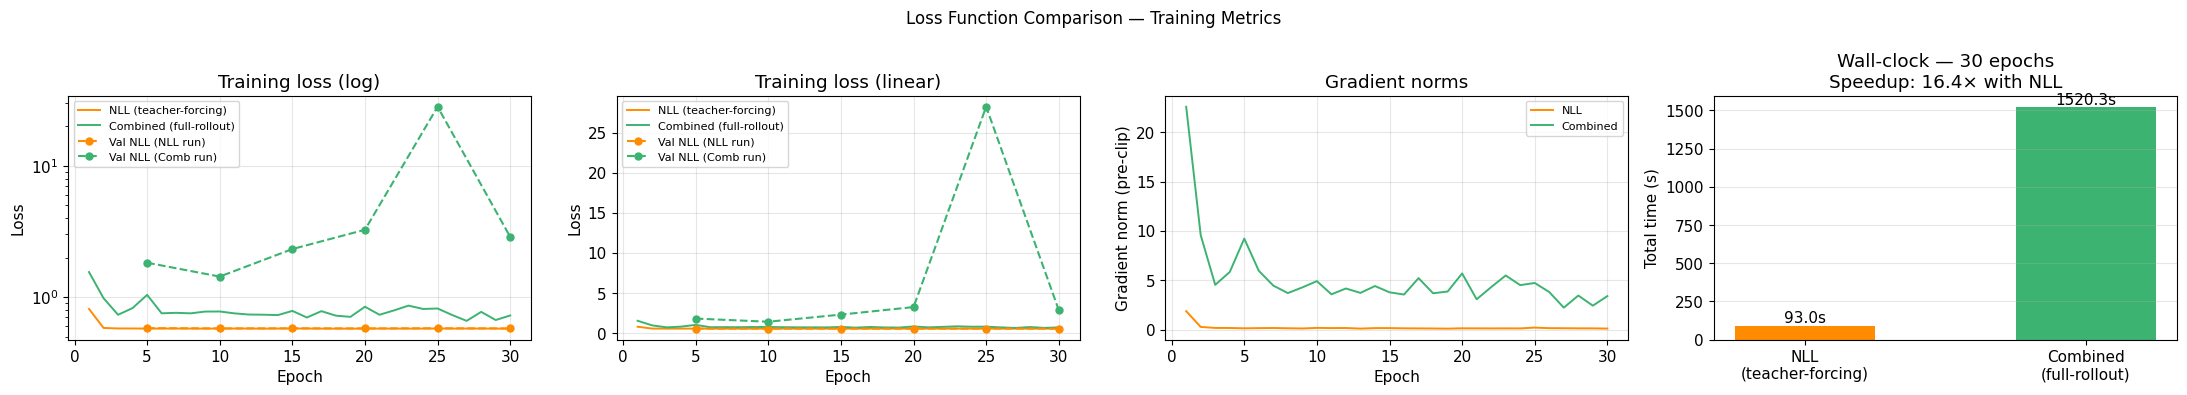

In [9]:
C_NLL  = "darkorange"
C_COMB = "mediumseagreen"
epochs = range(1, MAX_EPOCHS + 1)

fig, axes = plt.subplots(1, 4, figsize=(22, 4))

for ax, yscale in zip(axes[:2], ["log", "linear"]):
    ax.plot(epochs, result_nll.train_losses,  color=C_NLL,  lw=1.4, label="NLL (teacher-forcing)")
    ax.plot(epochs, result_comb.train_losses, color=C_COMB, lw=1.4, label="Combined (full-rollout)")
    if result_nll.val_nll_losses:
        ax.plot(result_nll.val_epochs,  result_nll.val_nll_losses,  "o--", color=C_NLL,  markersize=5, label="Val NLL (NLL run)")
        ax.plot(result_comb.val_epochs, result_comb.val_nll_losses, "o--", color=C_COMB, markersize=5, label="Val NLL (Comb run)")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.set_yscale(yscale)
    ax.set_title(f"Training loss ({yscale})"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[2]
if result_nll.grad_norms:
    ax.plot(epochs, result_nll.grad_norms,  color=C_NLL,  lw=1.4, label="NLL")
    ax.plot(epochs, result_comb.grad_norms, color=C_COMB, lw=1.4, label="Combined")
ax.set_xlabel("Epoch"); ax.set_ylabel("Gradient norm (pre-clip)")
ax.set_title("Gradient norms"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[3]
bars = ax.bar(["NLL\n(teacher-forcing)", "Combined\n(full-rollout)"],
              [elapsed_nll, elapsed_comb], color=[C_NLL, C_COMB], width=0.5)
for bar, val in zip(bars, [elapsed_nll, elapsed_comb]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{val:.1f}s", ha="center", va="bottom", fontsize=11)
ax.set_ylabel("Total time (s)")
ax.set_title(f"Wall-clock — {MAX_EPOCHS} epochs\nSpeedup: {elapsed_comb / elapsed_nll:.1f}× with NLL")
ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Loss Function Comparison — Training Metrics", fontsize=12)
plt.tight_layout(); plt.show()

## 6. Learned Dynamics

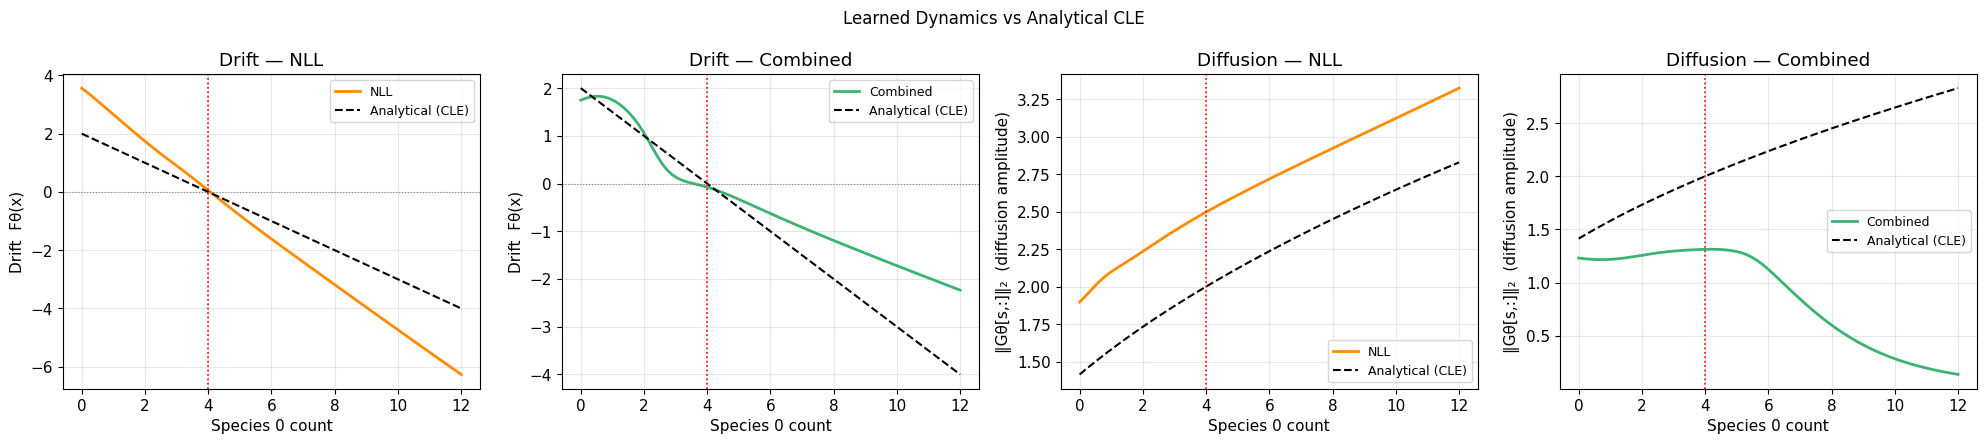

In [10]:
from crn_surrogate.evaluation import DynamicsVisualizer

state_range = torch.linspace(0.0, 12.0, 80)

viz_nll  = DynamicsVisualizer(encoder_nll,  sde_nll,  crn_repr, init_state)
viz_comb = DynamicsVisualizer(encoder_comb, sde_comb, crn_repr, init_state)

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

viz_nll.plot_drift(state_range, analytical_drift_fn=analytical["drift"],
                   label="NLL", color=C_NLL, ax=axes[0])
axes[0].set_title("Drift — NLL")

viz_comb.plot_drift(state_range, analytical_drift_fn=analytical["drift"],
                    label="Combined", color=C_COMB, ax=axes[1])
axes[1].set_title("Drift — Combined")

viz_nll.plot_diffusion(state_range, analytical_diffusion_fn=analytical["diffusion"],
                       label="NLL", color=C_NLL, ax=axes[2])
axes[2].set_title("Diffusion — NLL")

viz_comb.plot_diffusion(state_range, analytical_diffusion_fn=analytical["diffusion"],
                        label="Combined", color=C_COMB, ax=axes[3])
axes[3].set_title("Diffusion — Combined")

for ax in axes:
    ax.axvline(analytical["stationary_mean"], color="red", linestyle=":", lw=1.2)

plt.suptitle("Learned Dynamics vs Analytical CLE", fontsize=12)
plt.tight_layout(); plt.show()

## 7. Trajectory Quality

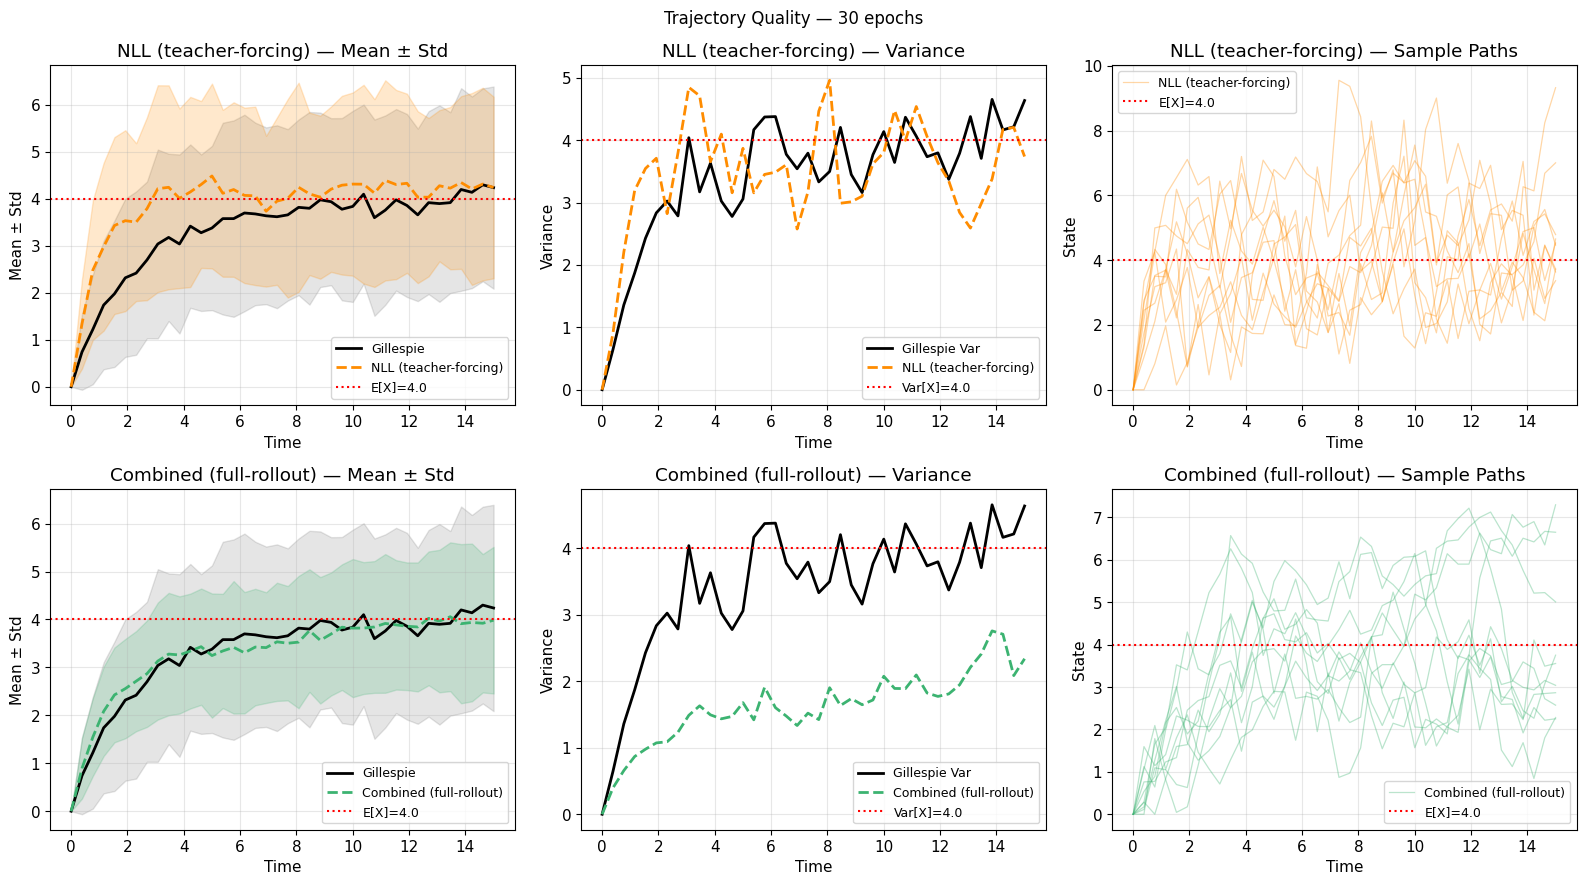

In [11]:
from crn_surrogate.evaluation import ModelEvaluator, TrajectoryComparator

eval_times = torch.linspace(0.0, T_MAX, N_GRID)
K_EVAL, M_EVAL = 50, 50

ssa_trajs = []
for _ in range(M_EVAL):
    result = ssa.simulate(crn.stoichiometry_matrix, crn.evaluate_propensities,
                          init_state.clone(), T_MAX)
    ssa_trajs.append(interpolate_to_grid(result.times, result.states, eval_times))
ssa_trajs = torch.stack(ssa_trajs)  # (M_EVAL, N_GRID, 1)

sde_trajs_nll  = ModelEvaluator(encoder_nll,  sde_nll,  sde_config).rollout(
    crn_repr, init_state, eval_times, dt=0.1, n_rollouts=K_EVAL)
sde_trajs_comb = ModelEvaluator(encoder_comb, sde_comb, sde_config).rollout(
    crn_repr, init_state, eval_times, dt=0.1, n_rollouts=K_EVAL)

comp_nll  = TrajectoryComparator(sde_trajs_nll,  ssa_trajs, eval_times,
                                 analytical_mean=analytical["stationary_mean"],
                                 analytical_var=analytical["stationary_var"])
comp_comb = TrajectoryComparator(sde_trajs_comb, ssa_trajs, eval_times,
                                 analytical_mean=analytical["stationary_mean"],
                                 analytical_var=analytical["stationary_var"])

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for row, (comp, label, color) in enumerate([
    (comp_nll,  "NLL (teacher-forcing)",   C_NLL),
    (comp_comb, "Combined (full-rollout)", C_COMB),
]):
    kw = {"sde_label": label, "sde_color": color}
    comp.plot_mean_std(**kw, ax=axes[row, 0])
    comp.plot_variance(**kw, ax=axes[row, 1])
    comp.plot_sample_paths(**kw, ax=axes[row, 2])
    axes[row, 0].set_title(f"{label} — Mean ± Std")
    axes[row, 1].set_title(f"{label} — Variance")
    axes[row, 2].set_title(f"{label} — Sample Paths")

plt.suptitle(f"Trajectory Quality — {MAX_EPOCHS} epochs", fontsize=12)
plt.tight_layout(); plt.show()

## 8. Residual Analysis

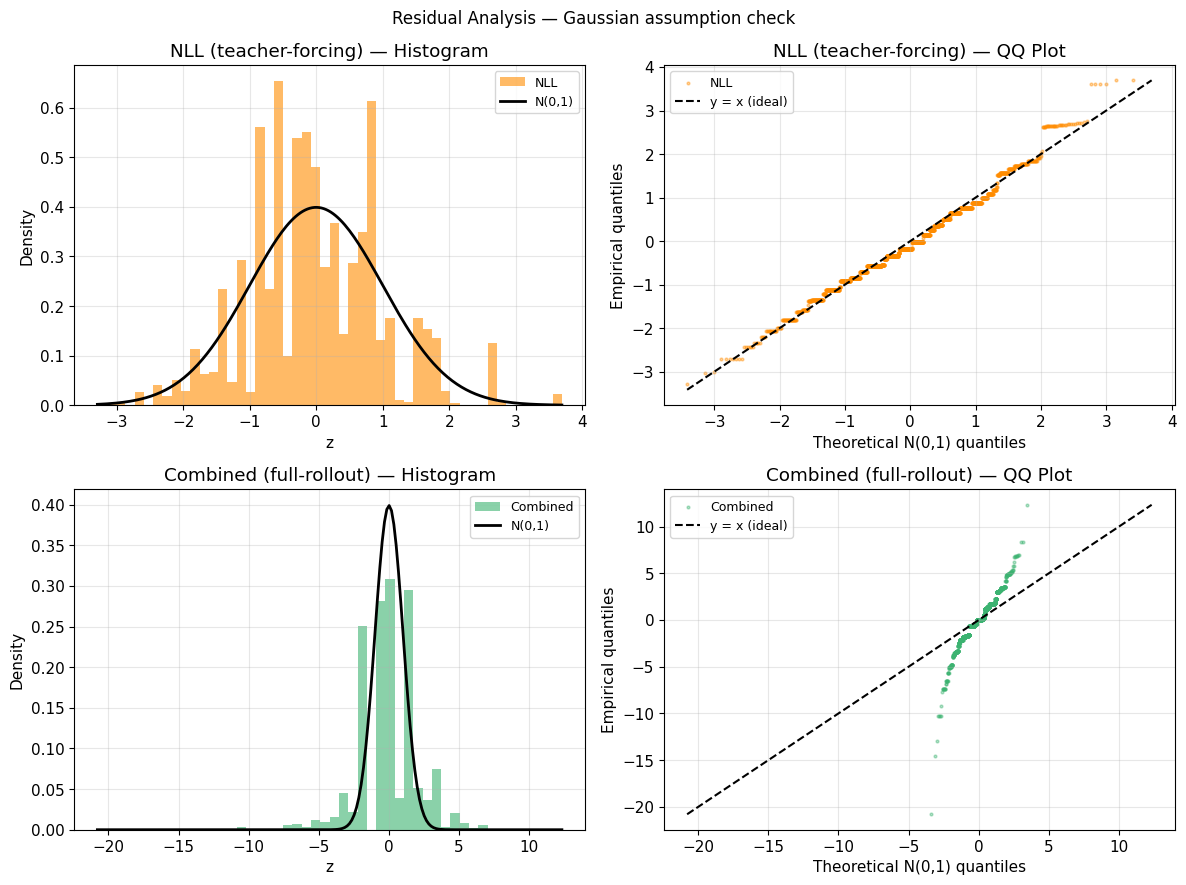

In [12]:
from crn_surrogate.evaluation import ResidualAnalyzer

report_nll  = ResidualAnalyzer(encoder_nll,  sde_nll,  crn_repr).compute_residuals(
    ssa_trajs, eval_times, dt=0.2, initial_state=init_state)
report_comb = ResidualAnalyzer(encoder_comb, sde_comb, crn_repr).compute_residuals(
    ssa_trajs, eval_times, dt=0.2, initial_state=init_state)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

ResidualAnalyzer(encoder_nll,  sde_nll,  crn_repr).plot_histogram(
    report_nll,  label="NLL",      color=C_NLL,  ax=axes[0, 0])
ResidualAnalyzer(encoder_nll,  sde_nll,  crn_repr).plot_qq(
    report_nll,  label="NLL",      color=C_NLL,  ax=axes[0, 1])
ResidualAnalyzer(encoder_comb, sde_comb, crn_repr).plot_histogram(
    report_comb, label="Combined", color=C_COMB, ax=axes[1, 0])
ResidualAnalyzer(encoder_comb, sde_comb, crn_repr).plot_qq(
    report_comb, label="Combined", color=C_COMB, ax=axes[1, 1])

for row, label in enumerate(["NLL (teacher-forcing)", "Combined (full-rollout)"]):
    axes[row, 0].set_title(f"{label} — Histogram")
    axes[row, 1].set_title(f"{label} — QQ Plot")

plt.suptitle("Residual Analysis — Gaussian assumption check", fontsize=12)
plt.tight_layout(); plt.show()

## 9. Summary Metrics

In [13]:
print(f"{'Metric':<28} {'NLL':>14} {'Combined':>14}  {'Better':>12}")
print("-" * 72)
for key in ["mean_mse", "var_mse", "final_mean", "final_var", "mean_sde_std"]:
    v_nll  = comp_nll.metrics()[key]
    v_comb = comp_comb.metrics()[key]
    if key in ("mean_mse", "var_mse"):
        better = "NLL ✓" if v_nll < v_comb else "Comb ✓"
    else:
        better = ""
    print(f"{key:<28} {v_nll:>14.4f} {v_comb:>14.4f}  {better:>12}")

print()
print(f"Residual mean (→0):  NLL={report_nll.mean[0].item():.3f}  Comb={report_comb.mean[0].item():.3f}")
print(f"Residual std  (→1):  NLL={report_nll.std[0].item():.3f}   Comb={report_comb.std[0].item():.3f}")
print(f"Residual kurt (→3):  NLL={report_nll.kurtosis[0].item():.2f}   Comb={report_comb.kurtosis[0].item():.2f}")
print()
print(f"Wall-clock:  NLL={elapsed_nll:.1f}s  Combined={elapsed_comb:.1f}s  Speedup={elapsed_comb / elapsed_nll:.1f}×")

Metric                                  NLL       Combined        Better
------------------------------------------------------------------------
mean_mse                             0.4812         0.0502        Comb ✓
var_mse                              0.7012         3.6035         NLL ✓
final_mean                           4.2336         3.9397              
final_var                            3.4434         2.1505              
mean_sde_std                         1.8199         1.2390              

Residual mean (→0):  NLL=-0.027  Comb=-0.009
Residual std  (→1):  NLL=0.998   Comb=2.249
Residual kurt (→3):  NLL=3.55   Comb=9.91

Wall-clock:  NLL=93.0s  Combined=1520.3s  Speedup=16.4×
